In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
import warnings

warnings.filterwarnings("ignore")

# Display all input files
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/datasets/binoyjose/smart-mcq-rag-knowledge-base-v1/chunks.csv
/kaggle/input/datasets/binoyjose/smart-mcq-rag-knowledge-base-v1/embeddings.npy
/kaggle/input/datasets/binoyjose/smart-mcq-rag-knowledge-base-v1/faiss.index
/kaggle/input/datasets/binoyjose/smart-mcq-rag-knowledge-base-v1/knowledge_base.csv
/kaggle/input/datasets/binoyjose/model5-roberta-pairwise/__huggingface_repos__.json
/kaggle/input/datasets/binoyjose/model5-roberta-pairwise/roberta_checkpoints/checkpoint-2500/config.json
/kaggle/input/datasets/binoyjose/model5-roberta-pairwise/roberta_checkpoints/checkpoint-2500/trainer_state.json
/kaggle/input/datasets/binoyjose/model5-roberta-pairwise/roberta_checkpoints/checkpoint-2500/training_args.bin
/kaggle/input/datasets/binoyjose/model5-roberta-pairwise/roberta_checkpoints/checkpoint-2500/scheduler.pt
/kaggle/input/datasets/binoyjose/model5-roberta-pairwise/roberta_checkpoints/checkpoint-2500/model.safetensors
/kaggle/input/datasets/binoyjose/model5-roberta-pairwi

# Introduction

This notebook presents the initial baseline solution for the Smart MCQ Solver Challenge, developed as part of the Deep Learning & Generative AI Project. The competition focuses on building intelligent machine learning models capable of predicting the top three most probable answers for challenging multiple-choice questions.

Each question consists of a prompt and five answer options (A, B, C, D, and E). Instead of predicting only the single correct answer, the model must rank the three most likely answers. Performance is evaluated using Mean Average Precision at 3 (MAP@3), which rewards models that rank the correct answer higher in the prediction list.

# Objectives

The objective of this project is to develop an intelligent multiple-choice question answering system capable of accurately predicting the top three most probable answers for each question using Natural Language Processing (NLP), Machine Learning, Deep Learning, and Generative AI techniques. The project involves understanding and preprocessing textual data, performing exploratory data analysis, building and evaluating baseline, classical machine learning, neural network, and transformer-based models, and comparing their performance using the Mean Average Precision at 3 (MAP@3) evaluation metric. Throughout the project, emphasis is placed on developing a systematic machine learning pipeline, improving model performance through experimentation and optimization, and gaining a comprehensive understanding of modern AI methodologies and their practical applications in automated question answering.

# Exploratory Data Analysis (EDA)

In [2]:
# Import Required Libraries

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

import warnings
warnings.filterwarnings("ignore")

In [3]:
# Load Dataset

train = pd.read_csv("/kaggle/input/competitions/smart-mcq-solver-challenge/train.csv")
test = pd.read_csv("/kaggle/input/competitions/smart-mcq-solver-challenge/test.csv")
sample = pd.read_csv("/kaggle/input/competitions/smart-mcq-solver-challenge/sample_submission.csv")

print("Train Shape :", train.shape)
print("Test Shape :", test.shape)
print("Sample Submission Shape :", sample.shape)

Train Shape : (2000, 8)
Test Shape : (500, 7)
Sample Submission Shape : (500, 2)


In [4]:
train.head()

,id,prompt,A,B,C,D,E,answer
0,1,Pick the best possible answer: What is Martin ...,Martin Heidegger believes that humans exist wi...,Martin Heidegger believes that humans do not e...,Martin Heidegger does not believe in the exist...,Martin Heidegger believes that the relationshi...,Martin Heidegger believes that time is an illu...,B
1,2,What is accelerator-based light-ion fusion?,Accelerator-based light-ion fusion is a techni...,Accelerator-based light-ion fusion is a techni...,Accelerator-based light-ion fusion is a techni...,Accelerator-based light-ion fusion is a techni...,Accelerator-based light-ion fusion is a techni...,A
2,3,Determine the correct option: What is the term...,Blueshifting,Redshifting,Reddening,Whitening,Yellowing,C
3,4,Select the most accurate option: What is Marti...,Martin Heidegger believes that humans exist wi...,Martin Heidegger believes that humans do not e...,Martin Heidegger does not believe in the exist...,Martin Heidegger believes that the relationshi...,Martin Heidegger believes that time is an illu...,B
4,5,Identify the correct statement: What is the co...,"Simultaneity is relative, meaning that two eve...","Simultaneity is relative, meaning that two eve...","Simultaneity is absolute, meaning that two eve...",Simultaneity is a concept that applies only to...,Simultaneity is a concept that applies only to...,A


**Dataset Information**

In [5]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 8 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   id      2000 non-null   int64 
 1   prompt  2000 non-null   object
 2   A       2000 non-null   object
 3   B       2000 non-null   object
 4   C       2000 non-null   object
 5   D       2000 non-null   object
 6   E       2000 non-null   object
 7   answer  2000 non-null   object
dtypes: int64(1), object(7)
memory usage: 125.1+ KB


he training dataset consists of 2,000 multiple-choice questions with 8 columns. Each row represents one question and contains a unique question identifier (id), the question prompt (prompt), five answer options (A, B, C, D, and E), and the corresponding correct answer (answer). The id column is of integer type (int64), while the remaining seven columns are of object type (object) since they contain textual data. The dataset structure confirms that it is well-organized

**Missing Values**

In [6]:
missing = train.isnull().sum().to_frame("Missing Values")
missing

,Missing Values
id,0
prompt,0
A,0
B,0
C,0
D,0
E,0
answer,0


The missing value analysis indicates that none of the columns contain missing or null values. Every column has 2,000 non-null entries, confirming that the dataset is complete. Since there are no missing values, no additional data imputation or preprocessing is required to handle incomplete records. This ensures that all observations can be used during model training and evaluation without any loss of information.

**Duplicate Rows**

In [7]:
print("Duplicate Rows :", train.duplicated().sum())

Duplicate Rows : 0


The duplicate row analysis shows that the dataset contains zero duplicate records. This indicates that every question in the dataset is unique, preventing redundant information from influencing the learning process. The absence of duplicate entries contributes to better model generalization and reduces the risk of biased training caused by repeated samples.

**Class Distribution**

In [8]:
answer_counts = train["answer"].value_counts()

print(answer_counts)

answer
B    490
C    459
A    369
D    358
E    324
Name: count, dtype: int64


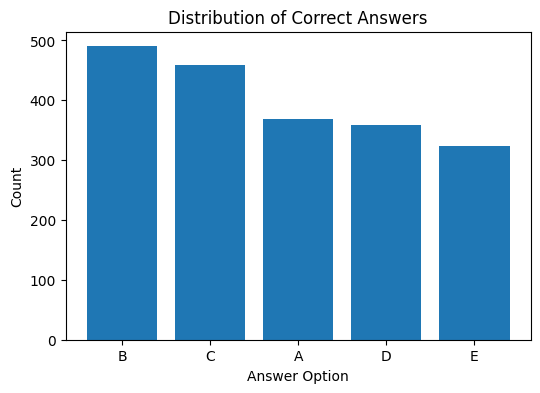

In [9]:
plt.figure(figsize=(6,4))
plt.bar(answer_counts.index, answer_counts.values)

plt.title("Distribution of Correct Answers")
plt.xlabel("Answer Option")
plt.ylabel("Count")

plt.show()

The distribution of the correct answer labels reveals that the dataset is reasonably balanced, although the classes are not perfectly equal. Option B is the most frequent correct answer with 490 occurrences, followed by C (459), A (369), D (358), and E (324). While the class frequencies vary slightly, the imbalance is not severe enough to significantly affect model training.

**Prompt Length Analysis**

In [10]:
# Creating a copy for training data for eda
eda_train = train.copy()

eda_train["Prompt Length"] = eda_train["prompt"].str.len()

eda_train["Prompt Length"].describe()

count    2000.000000
mean      117.669500
std        44.408674
min        19.000000
25%        87.750000
50%       111.000000
75%       141.000000
max       337.000000
Name: Prompt Length, dtype: float64

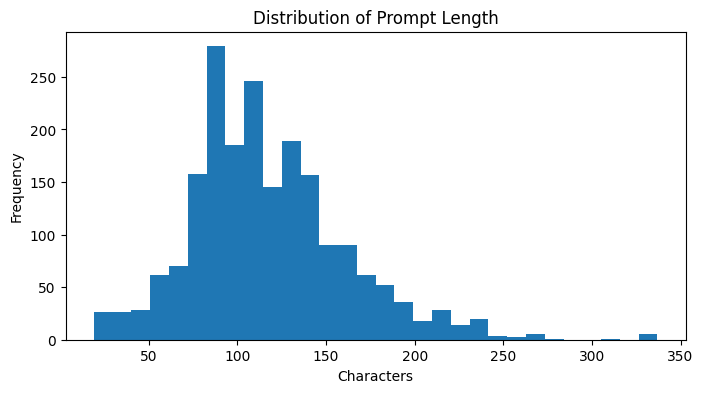

In [11]:
plt.figure(figsize=(8,4))

plt.hist(eda_train["Prompt Length"], bins=30)

plt.title("Distribution of Prompt Length")
plt.xlabel("Characters")
plt.ylabel("Frequency")

plt.show()

The prompt length analysis measures the number of characters present in each question prompt. The dataset contains 2,000 prompts, with an average length of approximately 118 characters. The shortest prompt contains 19 characters, while the longest consists of 337 characters, indicating considerable variation in question complexity and detail. Half of the prompts contain 111 characters or fewer, while 75% of the prompts have a length of 141 characters or less.

**Prompt Word Count Analysis**

In [12]:
eda_train["Prompt Word Count"] = eda_train["prompt"].str.split().apply(len)

eda_train["Prompt Word Count"].describe()

count    2000.00000
mean       18.14650
std         6.78189
min         3.00000
25%        14.00000
50%        17.00000
75%        22.00000
max        51.00000
Name: Prompt Word Count, dtype: float64

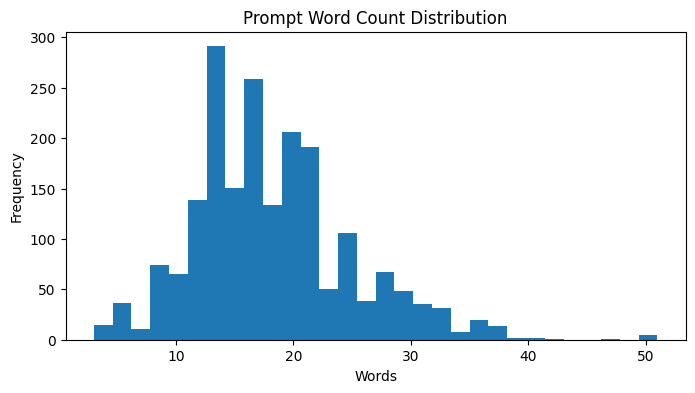

In [13]:
plt.figure(figsize=(8,4))

plt.hist(eda_train["Prompt Word Count"], bins=30)

plt.title("Prompt Word Count Distribution")
plt.xlabel("Words")
plt.ylabel("Frequency")

plt.show()

The prompt word count analysis examines the number of words contained in each question prompt. On average, each prompt consists of approximately 18 words, with the shortest prompt containing only 3 words and the longest containing 51 words. The median prompt length is 17 words, indicating that most questions are relatively concise while still providing sufficient contextual information.

**Option Length Analysis**

In [14]:
for option in ["A","B","C","D","E"]:
    eda_train[f"{option}_Length"] = eda_train[option].str.split().apply(len)

eda_train[[f"{c}_Length" for c in ["A","B","C","D","E"]]].describe()

,A_Length,B_Length,C_Length,D_Length,E_Length
count,2000.000000,2000.000000,2000.00000,2000.000000,2000.000000
mean,26.146000,26.516000,26.54950,25.999500,26.187000
std,17.249651,18.653893,17.20987,17.098909,17.852658
min,1.000000,1.000000,1.00000,1.000000,1.000000
25%,13.000000,12.000000,14.75000,15.000000,13.000000
50%,22.000000,23.000000,24.00000,22.000000,23.000000
75%,37.000000,36.000000,36.00000,36.000000,36.000000
max,81.000000,118.000000,82.00000,78.000000,105.000000


**Average option lengths**

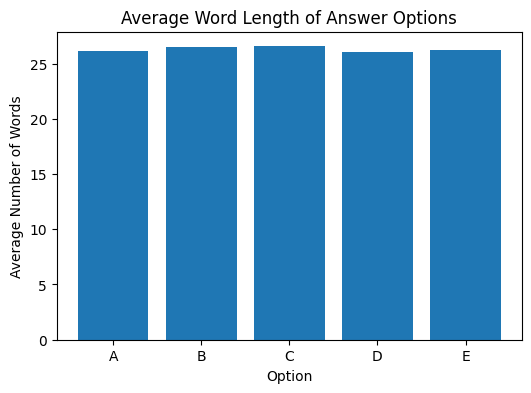

In [15]:
avg_lengths = []

for option in ["A","B","C","D","E"]:
    avg_lengths.append(eda_train[f"{option}_Length"].mean())

plt.figure(figsize=(6,4))

plt.bar(["A","B","C","D","E"], avg_lengths)

plt.title("Average Word Length of Answer Options")

plt.xlabel("Option")

plt.ylabel("Average Number of Words")

plt.show()

The answer option length analysis evaluates the number of words present in each of the five answer choices (A–E). The results show that all five options have a similar average length of approximately 26 words, indicating that the dataset has been designed with fairly balanced answer choices.

# Dummy Submission

In [16]:
import pandas as pd

sample = pd.read_csv("/kaggle/input/competitions/smart-mcq-solver-challenge/sample_submission.csv")

sample["Prediction"] = "A B C"

sample.to_csv("submission.csv", index=False)

sample.head()

,ID,Prediction
0,1,A B C
1,2,A B C
2,3,A B C
3,4,A B C
4,5,A B C


In [17]:
unique_options = pd.DataFrame({
    "Option": ["A", "B", "C", "D", "E"],
    "Unique Answer Choices": [train[col].nunique() for col in ["A", "B", "C", "D", "E"]]
})

unique_options

,Option,Unique Answer Choices
0,A,316
1,B,328
2,C,303
3,D,318
4,E,320


# Model 1 

# Baseline Model: TF-IDF + Cosine Similarity

The first model in this project is a simple baseline model built using TF-IDF (Term Frequency–Inverse Document Frequency) and Cosine Similarity. The goal of this model is to understand how well a traditional Natural Language Processing (NLP) approach can solve multiple-choice questions without using any deep learning techniques.

In [18]:
# Important Libraries

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

# For checking the accuracy
from sklearn.metrics import (accuracy_score,precision_score,recall_score,f1_score)

In [19]:
#Logging into Weights and Biases

from kaggle_secrets import UserSecretsClient
import wandb

user_secrets = UserSecretsClient()
api_key = user_secrets.get_secret("WANDB_API_KEY")

wandb.login(key=api_key)

wandb.init(
    entity="25ds1000066-dl-genai-project",
    project="25ds1000066-t22026",
    name="Model1_TFIDF",
    config={
        "model": "TF-IDF",
        "similarity": "Cosine Similarity"
    }
)

wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: [wandb.login()] Using explicit session credentials for https://api.wandb.ai.
wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: W&B API key is configured. Use `wandb login --relogin` to force relogin
wandb: Tracking run with wandb version 0.25.1
wandb: Run data is saved locally in /kaggle/working/wandb/run-20260804_095337-e665pwf9
wandb: Run `wandb offline` to turn off syncing.
wandb: Syncing run Model1_TFIDF
wandb: ⭐️ View project at https://wandb.ai/25ds1000066-dl-genai-project/25ds1000066-t22026
wandb: 🚀 View run at https://wandb.ai/25ds1000066-dl-genai-project/25ds1000066-t22026/runs/e665pwf9


In [20]:
# Cleaning Data
import string
import re

def clean_text(text):
    # Convert to lowercase
    text = text.lower()

    # Remove punctuation
    text = text.translate(str.maketrans('', '', string.punctuation))

    # Remove extra spaces
    text = re.sub(r'\s+', ' ', text).strip()

    return text

In [21]:
train_clean = train.copy()
test_clean = test.copy()

# Clean prompt
train_clean["prompt"] = train_clean["prompt"].apply(clean_text)
test_clean["prompt"] = test_clean["prompt"].apply(clean_text)

# Clean options
for option in ["A", "B", "C", "D", "E"]:
    train_clean[option] = train_clean[option].apply(clean_text)
    test_clean[option] = test_clean[option].apply(clean_text)

In [22]:
from sklearn.model_selection import train_test_split

train_split, valid_split = train_test_split(
    train_clean,
    test_size=0.2,
    random_state=42,
    shuffle=True
)

print(train_split.shape)
print(valid_split.shape)

(1600, 8)
(400, 8)


In [23]:
# Create combined Corpus
combined_text = (
    train_split["prompt"] + " " +
    train_split["A"] + " " +
    train_split["B"] + " " +
    train_split["C"] + " " +
    train_split["D"] + " " +
    train_split["E"]
)

In [24]:
# Fir TF IDF 

vectorizer = TfidfVectorizer(stop_words="english")

vectorizer.fit(combined_text)

TfidfVectorizer(stop_words='english')

In [25]:
# Creating MAP@3 Function

# Function to calculate Average Precision at K (AP@K) for a single prediction
def apk(actual, predicted, k=3):

    if len(predicted) > k:                   # Keep only the top-k predictions
        predicted = predicted[:k]            

    for i, p in enumerate(predicted):        # Iterate through the predicted labels
        if p == actual:                      # If the correct answer is found, return the score
            return 1 / (i + 1)

    return 0                                 # Return 0 if the correct answer is not in the top-k predictions


# Function to calculate Mean Average Precision at K (MAP@K)
def mapk(actuals, predictions, k=3):
    
    # Compute the average AP@K score over the entire dataset
    return sum(apk(a, p, k) for a, p in zip(actuals, predictions)) / len(actuals)

In [26]:
# Generate Top-3 Predictions using TF-IDF Cosine Similarity

# Store the top-3 predictions for every question
predictions = []

# Store Top-1 predictions
tfidf_top1_predictions = []

for _, row in valid_split.iterrows():                             # Iterate through every question in the training dataset

    prompt_vec = vectorizer.transform([row["prompt"]])            # Convert the question prompt into a TF-IDF vector

    similarities = []                                             # Store cosine similarity scores for all answer options

    for option in ["A", "B", "C", "D", "E"]:                      # Compare the prompt with each of the five answer options

        option_vec = vectorizer.transform([row[option]])          # Convert the current answer option into a TF-IDF vector

        sim = cosine_similarity(prompt_vec, option_vec)[0][0]     # Calculate cosine similarity between the prompt and the answer option

        similarities.append((option, sim))                        # Save the option label together with its similarity score

    similarities.sort(key=lambda x: x[1], reverse=True)           # Sort answer options in descending order of cosine similarity

    top3 = [x[0] for x in similarities[:3]]                       # Select the three most similar answer options

   
    top1_tfidf = similarities[0][0]                               # Secleting the Top-1 prediction

    predictions.append(top3)                                      # Store the top-3 predictions for the current question

    tfidf_top1_predictions.append(top1_tfidf)                     # Store the top-1 predictions for the current question for checking the accuracy

In [27]:
# Evalutaion

tfidf_map3 = mapk(valid_split["answer"], predictions)

print(f"TF-IDF Baseline MAP@3 : {tfidf_map3:.4f}")

TF-IDF Baseline MAP@3 : 0.2783


In [28]:
# Actual answers
actual_answers = valid_split["answer"]

# Accuracy
tfidf_accuracy = accuracy_score(actual_answers,tfidf_top1_predictions)

# Precision
tfidf_precision = precision_score(actual_answers,tfidf_top1_predictions,average="macro")

# Recall
tfidf_recall = recall_score(actual_answers,tfidf_top1_predictions,average="macro")

# F1 Score
tfidf_f1 = f1_score(actual_answers,tfidf_top1_predictions,average="macro")

print(f"Accuracy : {tfidf_accuracy:.4f}")
print(f"Precision : {tfidf_precision:.4f}")
print(f"Recall : {tfidf_recall:.4f}")
print(f"F1 Score : {tfidf_f1:.4f}")

Accuracy : 0.1075
Precision : 0.0986
Recall : 0.1140
F1 Score : 0.0973


In [29]:
wandb.log({
    "Accuracy": tfidf_accuracy,
    "Precision": tfidf_precision,
    "Recall": tfidf_recall,
    "F1 Score": tfidf_f1,
    "MAP@3": tfidf_map3,
    "Kaggle Score": 0.30922
})

wandb.finish()

wandb: updating run metadata; uploading console lines 0-0
wandb: uploading console lines 0-0
wandb: uploading console lines 0-0; uploading wandb-metadata.json; uploading output.log; uploading wandb-summary.json
wandb: uploading console lines 0-0
wandb: uploading history steps 0-0, summary, console lines 1-6
wandb: 
wandb: Run history:
wandb:     Accuracy ▁
wandb:     F1 Score ▁
wandb: Kaggle Score ▁
wandb:        MAP@3 ▁
wandb:    Precision ▁
wandb:       Recall ▁
wandb: 
wandb: Run summary:
wandb:     Accuracy 0.1075
wandb:     F1 Score 0.09733
wandb: Kaggle Score 0.30922
wandb:        MAP@3 0.27833
wandb:    Precision 0.09857
wandb:       Recall 0.11403
wandb: 
wandb: 🚀 View run Model1_TFIDF at: https://wandb.ai/25ds1000066-dl-genai-project/25ds1000066-t22026/runs/e665pwf9
wandb: ⭐️ View project at: https://wandb.ai/25ds1000066-dl-genai-project/25ds1000066-t22026
wandb: Synced 5 W&B file(s), 0 media file(s), 0 artifact file(s) and 0 other file(s)
wandb: Find logs at: ./wandb/run-2026

**Prediction on Test Data**

In [30]:
# Generate Top-3 Predictions for the Test Dataset

tfidf_test_predictions = []

# Iterate through every question in the test dataset
for _, row in test_clean.iterrows():

    # Convert the question prompt into a TF-IDF vector
    prompt_vec = vectorizer.transform([row["prompt"]])

    similarities = []

    # Calculate cosine similarity between the prompt and each answer option
    for option in ["A", "B", "C", "D", "E"]:

        option_vec = vectorizer.transform([row[option]])

        sim = cosine_similarity(prompt_vec, option_vec)[0][0]

        similarities.append((option, sim))

    # Sort options by similarity score (highest first)
    similarities.sort(key=lambda x: x[1], reverse=True)

    # Select the top 3 predicted answer labels
    top3 = [x[0] for x in similarities[:3]]

    tfidf_test_predictions.append(top3)

In [31]:
# Create Submission File

submission = pd.DataFrame({
    "id": test["id"],
    "prediction": [" ".join(pred) for pred in tfidf_test_predictions]
})

submission.head()

,id,prediction
0,1,A B C
1,2,A B C
2,3,A D C
3,4,A E C
4,5,A E C


In [32]:
# Save submission file
submission.to_csv("submission.csv", index=False)

In this baseline implementation, exploratory data analysis and text preprocessing were performed to better understand the dataset and prepare it for modeling. A classical Natural Language Processing approach using TF-IDF vectorization and cosine similarity was implemented to rank the five answer options for each multiple-choice question. The model was evaluated using the Mean Average Precision at 3 (MAP@3) metric, achieving a training MAP@3 score of 0.2962 and a Kaggle public leaderboard score of 0.30922. Although the TF-IDF baseline provides a simple and computationally efficient solution, it relies primarily on lexical similarity and does not capture contextual meaning or semantic relationships between the question prompt and answer options.

In [33]:
from huggingface_hub import login
from kaggle_secrets import UserSecretsClient

user_secrets = UserSecretsClient()
hf_token = user_secrets.get_secret("HF_TOKEN")

login(token=hf_token)

# Model 2

# Sentence Transformer (MiniLM)

Sentence Transformers generate dense semantic embeddings that capture the contextual meaning of entire sentences. Unlike TF-IDF, which relies on exact word overlap, Sentence Transformers understand semantic relationships between texts, making them more suitable for ranking multiple-choice answers based on meaning.

In [34]:
# W&B Login

user_secrets = UserSecretsClient()
api_key = user_secrets.get_secret("WANDB_API_KEY")

wandb.login(key=api_key)

wandb.init(
    entity="25ds1000066-dl-genai-project",
    project="25ds1000066-t22026",
    name="Model2_MiniLM",
    config={
        "model": "MiniLM",
        "embedding_model": "all-MiniLM-L6-v2",
        "similarity": "Cosine Similarity"
    }
)

wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: WARNING [wandb.login()] Changing session credentials to explicit value for https://api.wandb.ai.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: setting up run yl602rfl
wandb: Tracking run with wandb version 0.25.1
wandb: Run data is saved locally in /kaggle/working/wandb/run-20260804_095422-yl602rfl
wandb: Run `wandb offline` to turn off syncing.
wandb: Syncing run Model2_MiniLM
wandb: ⭐️ View project at https://wandb.ai/25ds1000066-dl-genai-project/25ds1000066-t22026
wandb: 🚀 View run at https://wandb.ai/25ds1000066-dl-genai-project/25ds1000066-t22026/runs/yl602rfl


In [35]:
# Loading the libraries
from sentence_transformers import SentenceTransformer, util

In [36]:
# Load pretrained MiniLM Sentence Transformer
model = SentenceTransformer("sentence-transformers/all-MiniLM-L6-v2")

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/350 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

In [37]:
# Generate Predictions

# Store Top-3 predictions
minilm_predictions = []

# Store top-1 prediction
minilm_top1_predictions = []

# Iterate through every question
for _, row in valid_split.iterrows():

    # Encode prompt
    prompt_embedding = model.encode(
        row["prompt"],
        convert_to_tensor=True
    )

    similarities = []

    # Compare prompt with each option
    for option in ["A", "B", "C", "D", "E"]:

        option_embedding = model.encode(
            row[option],
            convert_to_tensor=True
        )

        similarity = util.cos_sim(
            prompt_embedding,
            option_embedding
        ).item()

        similarities.append((option, similarity))

    # Rank options
    similarities.sort(key=lambda x: x[1],reverse=True)
    
    
    # select top3 predictions
    top3_minlm_predictions = [x[0] for x in similarities[:3]]
    # select top1 predictions
    top1_minilm = similarities[0][0]


    #Store Predictions
    minilm_predictions.append(top3_minlm_predictions)
    minilm_top1_predictions.append(top1_minilm)

In [38]:
#Evaluation
minilm_map3 = mapk(valid_split["answer"],minilm_predictions)

print(f"MiniLM MAP@3 : {minilm_map3:.4f}")

MiniLM MAP@3 : 0.3771


In [39]:
# Actual answers
actual_answers = valid_split["answer"]

# Accuracy
minilm_accuracy = accuracy_score(actual_answers,minilm_top1_predictions)

# Precision
minilm_precision = precision_score(actual_answers,minilm_top1_predictions,average="macro")

# Recall
minilm_recall = recall_score(actual_answers,minilm_top1_predictions,average="macro")

# F1 Score
minilm_f1 = f1_score(actual_answers,minilm_top1_predictions,average="macro")

print(f"Accuracy : {minilm_accuracy:.4f}")
print(f"Precision : {minilm_precision:.4f}")
print(f"Recall : {minilm_recall:.4f}")
print(f"F1 Score : {minilm_f1:.4f}")

Accuracy : 0.2400
Precision : 0.2413
Recall : 0.2484
F1 Score : 0.2398


In [40]:
wandb.log({
    "Accuracy": minilm_accuracy,
    "Precision": minilm_precision,
    "Recall": minilm_recall,
    "F1 Score": minilm_f1,
    "MAP@3": minilm_map3,
    "Kaggle Score": 0.38653
})

wandb.finish()

wandb: uploading console lines 0-6; updating run metadata
wandb: uploading console lines 0-6
wandb: uploading console lines 0-6; uploading config.yaml
wandb: uploading console lines 0-6
wandb: uploading history steps 0-0, summary, console lines 7-11
wandb: 
wandb: Run history:
wandb:     Accuracy ▁
wandb:     F1 Score ▁
wandb: Kaggle Score ▁
wandb:        MAP@3 ▁
wandb:    Precision ▁
wandb:       Recall ▁
wandb: 
wandb: Run summary:
wandb:     Accuracy 0.24
wandb:     F1 Score 0.23977
wandb: Kaggle Score 0.38653
wandb:        MAP@3 0.37708
wandb:    Precision 0.2413
wandb:       Recall 0.24839
wandb: 
wandb: 🚀 View run Model2_MiniLM at: https://wandb.ai/25ds1000066-dl-genai-project/25ds1000066-t22026/runs/yl602rfl
wandb: ⭐️ View project at: https://wandb.ai/25ds1000066-dl-genai-project/25ds1000066-t22026
wandb: Synced 5 W&B file(s), 0 media file(s), 0 artifact file(s) and 0 other file(s)
wandb: Find logs at: ./wandb/run-20260804_095422-yl602rfl/logs


**Prediction on Test Data**

In [41]:
minilm_test_predictions = []

for _, row in test.iterrows():

    prompt_embedding = model.encode(
        row["prompt"],
        convert_to_tensor=True
    )

    similarities = []

    for option in ["A","B","C","D","E"]:

        option_embedding = model.encode(
            row[option],
            convert_to_tensor=True
        )

        similarity = util.cos_sim(
            prompt_embedding,
            option_embedding
        ).item()

        similarities.append((option, similarity))

    similarities.sort(
        key=lambda x: x[1],
        reverse=True
    )

    top3_test_minilm_predictions = [x[0] for x in similarities[:3]]

    minilm_test_predictions.append(" ".join(top3_test_minilm_predictions))

In [42]:
submission = sample.copy()

submission["Prediction"] = minilm_test_predictions

submission.to_csv("submission.csv", index=False)

submission.head()

,ID,Prediction
0,1,B E A
1,2,B D C
2,3,A C D
3,4,A E C
4,5,B C D


The Sentence Transformer (all-MiniLM-L6-v2) model demonstrated a substantial improvement over the TF-IDF baseline by utilizing contextual sentence embeddings rather than sparse lexical features. The model achieved a local MAP@3 score of 0.4231 and a Kaggle public leaderboard score of 0.38653, outperforming the TF-IDF baseline in both local evaluation and competition performance. This improvement indicates that semantic embeddings are more effective at capturing the contextual relationship between the question prompt and answer options. However, the results also suggest that there is still considerable room for improvement, motivating the exploration of more powerful embedding models and transformer-based architectures in subsequent experiments.

# Model 3

# Multilayer Perceptron 

The third model in this project is a Multi-Layer Perceptron (MLP) built completely from scratch using PyTorch. Unlike the previous models that rely on similarity-based methods, this model learns to classify the correct answer by training a neural network on the dataset.

The input features are first converted into numerical vectors using TF-IDF, and these vectors are then fed into the MLP. The network consists of fully connected (linear) layers, activation functions, and dropout layers, which help the model learn meaningful patterns while reducing overfitting.

In [43]:
# Deep Learning Libraries
import torch
import torch.nn as nn
import torch.optim as optim

# Dataset Utilities
from torch.utils.data import Dataset, DataLoader

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer

# Others
import numpy as np
import pandas as pd

In [44]:
from kaggle_secrets import UserSecretsClient
import wandb


#Logging in Weights and Biases

user_secrets = UserSecretsClient()

api_key = user_secrets.get_secret("WANDB_API_KEY")

wandb.login(key=api_key)

# Project details
wandb.init(
    entity="25ds1000066-dl-genai-project",
    project="25ds1000066-t22026",
    name="Model3_MLP_TFIDF",
    config={
        "model": "MLP",
        "input_features": "TF-IDF",
        "optimizer": "Adam",
        "loss_function": "CrossEntropyLoss"
    }
)

wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: WARNING [wandb.login()] Changing session credentials to explicit value for https://api.wandb.ai.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: setting up run 1b7mjwnu
wandb: Tracking run with wandb version 0.25.1
wandb: Run data is saved locally in /kaggle/working/wandb/run-20260804_095609-1b7mjwnu
wandb: Run `wandb offline` to turn off syncing.
wandb: Syncing run Model3_MLP_TFIDF
wandb: ⭐️ View project at https://wandb.ai/25ds1000066-dl-genai-project/25ds1000066-t22026
wandb: 🚀 View run at https://wandb.ai/25ds1000066-dl-genai-project/25ds1000066-t22026/runs/1b7mjwnu


This model is the first deep learning model developed completely from scratch for the Smart MCQ Solver Challenge. Instead of using cosine similarity to rank answers, a Multi-Layer Perceptron (MLP) is trained to learn patterns from TF-IDF features and predict the correct answer option. The model is implemented using PyTorch and trained using backpropagation and gradient descent.

In [45]:
# Split original questions
train_questions, valid_questions = train_test_split(
    train,
    test_size=0.2,
    random_state=42,
    shuffle=True
)

print("Training Questions :", len(train_questions))
print("Validation Questions :", len(valid_questions))

Training Questions : 1600
Validation Questions : 400


In [46]:
# Create pairwise training data

def create_pairwise_dataset(dataframe):
# Create an empty list to store the new pairwise dataset
    pairwise_data = []

    for _, row in dataframe.iterrows():                                     # Loop through every question in the training dataset

        prompt = row["prompt"]                                          # Extract the question prompt
        correct_answer = row["answer"]                                  # Get the correct answer label (A, B, C, D or E)

        for option in ["A", "B", "C", "D", "E"]:                        # Loop through all five answer options
        
        # Create one training sample consisting of:Question + one answer option
            pairwise_data.append({
                "text": prompt + " " + row[option],                    # Combine question and option into one text input

    
                # Assign label:
                # 1 = Correct option
                # 0 = Incorrect option
                "label": 1 if option == correct_answer else 0
        })

    return pd.DataFrame(pairwise_data)


# Convert the list into a Pandas DataFrame
pairwise_train = create_pairwise_dataset(train_questions)

pairwise_valid = create_pairwise_dataset(valid_questions)

print(pairwise_train.shape)
print(pairwise_valid.shape)

(8000, 2)
(2000, 2)


The original dataset contains one row per question with five answer options. Since our MLP is designed as a binary classifier (Correct/Incorrect), we transform each question into five separate training samples by pairing the prompt with each answer option. The correct option receives a label of 1, while the remaining options receive 0.

In [47]:
# Create TF-IDF Vectorizer
vectorizer = TfidfVectorizer(
    stop_words="english",
    max_features=5000
)

# Fit only on training data
X_train = vectorizer.fit_transform(pairwise_train["text"])

# Transform validation data
X_valid = vectorizer.transform(pairwise_valid["text"])

# Labels
y_train = pairwise_train["label"].values
y_valid = pairwise_valid["label"].values

In [48]:
# Convert sparse matrices to dense arrays
X_train = X_train.toarray()
X_valid = X_valid.toarray()

# Convert to PyTorch tensors
X_train_tensor = torch.FloatTensor(X_train)
X_valid_tensor = torch.FloatTensor(X_valid)

y_train_tensor = torch.LongTensor(y_train)
y_valid_tensor = torch.LongTensor(y_valid)

print("Training Tensor Shape :", X_train_tensor.shape)
print("Validation Tensor Shape :", X_valid_tensor.shape)

Training Tensor Shape : torch.Size([8000, 2761])
Validation Tensor Shape : torch.Size([2000, 2761])


In [49]:
# Custom Dataset

# Define a custom dataset class
class MCQDataset(Dataset):

    def __init__(self, features, labels):                      # Initialize the dataset with features and labels

        self.features = features                               # Store feature vectors
        self.labels = labels                                   # Store corresponding labels

    def __len__(self):                                         # function for Return the total number of samples

        return len(self.labels)
    
    def __getitem__(self, index):                              # function for Return one sample (feature, label) at the given index

        return self.features[index], self.labels[index]

PyTorch trains models using Dataset objects. This custom dataset stores the feature vectors and labels together, allowing the DataLoader to efficiently load batches of training data during model training

In [50]:
# Creating Dataset objects

# Create dataset object for training data
train_dataset = MCQDataset(
    X_train_tensor,
    y_train_tensor
)

# Create dataset object for validation data
valid_dataset = MCQDataset(
    X_valid_tensor,
    y_valid_tensor
)

After creating the custom Dataset class, we create separate dataset objects for the training and validation sets. These objects will later be passed to the DataLoader.

In [51]:
# Creating Dataloaders

# Create DataLoader for training
train_loader = DataLoader(
    train_dataset,
    batch_size=64,                  # Number of samples processed at a time
    shuffle=True                    # Shuffle data every epoch to improve learning
)
# Create DataLoader for validation
valid_loader = DataLoader(
    valid_dataset,
    batch_size=64,
    shuffle=False                    # Keep validation order fixed
)

The DataLoader loads the dataset in small batches instead of loading the entire dataset at once. This improves memory efficiency and speeds up neural network training.

In [52]:
#Defining Model

# Multi-Layer Perceptron Model
class MLPClassifier(nn.Module):

    def __init__(self, input_size):            # Initialize the neural network

        super().__init__()                     # Call the parent class constructor

        self.network = nn.Sequential(          # Build the neural network

            nn.Linear(input_size, 512),        # First hidden layer
            nn.ReLU(),                         # Activation function
            nn.Dropout(0.3),                   # Dropout layer to reduce overfitting

            nn.Linear(512, 128),               # Second hidden layer
            nn.ReLU(),                         # Activation function
            nn.Dropout(0.3),                   # Dropout layer
            
            
            # Output layer
            # Produces scores for two classes:
            # 0 = Incorrect
            # 1 = Correct
            nn.Linear(128, 2)                  

        )
    # Forward pass through the network
    def forward(self, x):

        return self.network(x)

This defines the Multi-Layer Perceptron (MLP) architecture. The model learns patterns from TF-IDF features and predicts whether a given question-option pair is correct (1) or incorrect (0).

In [53]:
# Select GPU if available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Initialize model
mlp_model = MLPClassifier(
    input_size=X_train.shape[1]
).to(device)

print(mlp_model)

MLPClassifier(
  (network): Sequential(
    (0): Linear(in_features=2761, out_features=512, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=512, out_features=128, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.3, inplace=False)
    (6): Linear(in_features=128, out_features=2, bias=True)
  )
)


In [54]:
#Defining loss function

# Loss Function
criterion = nn.CrossEntropyLoss()

# Optimizer
optimizer = optim.Adam(
    mlp_model.parameters(),
    lr=0.001
)

In [55]:
# Training Loop
# --------------

num_epochs = 10

# Store losses for plotting
train_losses = []
valid_losses = []

# Train the model
for epoch in range(num_epochs):

    # Training Phase
    # ---------------

    mlp_model.train()

    running_loss = 0
    correct = 0
    total = 0

    for features, labels in train_loader:

        # Move data to GPU
        features = features.to(device)
        labels = labels.to(device)

        # Clear old gradients
        optimizer.zero_grad()

        # Forward pass
        outputs = mlp_model(features)

        # Calculate loss
        loss = criterion(outputs, labels)

        # Backpropagation
        loss.backward()

        # Update weights
        optimizer.step()

        running_loss += loss.item()

        # Training Accuracy
        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    # Average Training Loss & Accuracy
    epoch_loss = running_loss / len(train_loader)
    epoch_accuracy = correct / total

    train_losses.append(epoch_loss)

    
    # Validation Phase
    # ------------------

    mlp_model.eval()                              

    valid_loss = 0                                 # Initialize validation loss
    valid_correct = 0                              # Initialize correct prediction counter
    valid_total = 0                                # Initialize total sample counter

    with torch.no_grad():                          # Disable gradient calculation during valid

        for features, labels in valid_loader:      # Loop through every validation batch

            features = features.to(device)         # Move data to GPU (or CPU)
            labels = labels.to(device)

            outputs = mlp_model(features)          # Forward pass

            loss = criterion(outputs, labels)      # Compute validation loss

            valid_loss += loss.item()              # Accumulate batch loss

            _, predicted = torch.max(outputs, 1)   # Get predicted class

            valid_total += labels.size(0)          # Count total validation samples
            valid_correct += (predicted == labels).sum().item()        # Count correctly classified samples

    # Average Validation Loss & Accuracy
    validation_loss = valid_loss / len(valid_loader)
    validation_accuracy = valid_correct / valid_total

    valid_losses.append(validation_loss)

    # Print Progress
    # ----------------

    print(
        f"Epoch [{epoch+1}/{num_epochs}] | "
        f"Train Loss: {epoch_loss:.4f} | "
        f"Train Acc: {epoch_accuracy:.4f} | "
        f"Valid Loss: {validation_loss:.4f} | "
        f"Valid Acc: {validation_accuracy:.4f}"
    )

    # Log to Weights & Biases
    # -------------------------

    wandb.log({
        "Epoch": epoch + 1,
        "Training Loss": epoch_loss,
        "Training Accuracy": epoch_accuracy,
        "Validation Loss": validation_loss,
        "Validation Accuracy": validation_accuracy
    })

Epoch [1/10] | Train Loss: 0.4824 | Train Acc: 0.8000 | Valid Loss: 0.3763 | Valid Acc: 0.8000
Epoch [2/10] | Train Loss: 0.2853 | Train Acc: 0.8652 | Valid Loss: 0.1951 | Valid Acc: 0.9195
Epoch [3/10] | Train Loss: 0.1726 | Train Acc: 0.9303 | Valid Loss: 0.1448 | Valid Acc: 0.9350
Epoch [4/10] | Train Loss: 0.1343 | Train Acc: 0.9390 | Valid Loss: 0.1046 | Valid Acc: 0.9570
Epoch [5/10] | Train Loss: 0.1094 | Train Acc: 0.9545 | Valid Loss: 0.0970 | Valid Acc: 0.9610
Epoch [6/10] | Train Loss: 0.0924 | Train Acc: 0.9600 | Valid Loss: 0.0786 | Valid Acc: 0.9650
Epoch [7/10] | Train Loss: 0.0818 | Train Acc: 0.9616 | Valid Loss: 0.0719 | Valid Acc: 0.9660
Epoch [8/10] | Train Loss: 0.0717 | Train Acc: 0.9647 | Valid Loss: 0.0750 | Valid Acc: 0.9660
Epoch [9/10] | Train Loss: 0.0702 | Train Acc: 0.9683 | Valid Loss: 0.0654 | Valid Acc: 0.9705
Epoch [10/10] | Train Loss: 0.0651 | Train Acc: 0.9665 | Valid Loss: 0.0696 | Valid Acc: 0.9635


Before training the neural network, we define the loss function, optimizer, and training parameters. The loss function measures the prediction error, while the optimizer updates the model weights using backpropagation. The training loop repeatedly processes batches of data over multiple epochs, allowing the model to learn patterns from the training dataset. Training loss and accuracy are also logged to Weights & Biases (W&B) for experiment tracking.

After training, we evaluate the model on the validation dataset to measure how well it performs on unseen data. Validation loss and accuracy help determine whether the model has learned useful patterns or has overfitted the training data.

In [56]:

mlp_model.eval()

# To store Top-3 predictions
mlp_predictions = []

# To store top 1 predictions
mlp_top1_predictions = []

# Disable gradient calculation
with torch.no_grad():

    # Loop through every question
    for _, row in valid_questions.iterrows():

        option_scores = []

        # Evaluate each option
        for option in ["A", "B", "C", "D", "E"]:

            # Combine prompt and option
            text = row["prompt"] + " " + row[option]

            # Convert to TF-IDF
            text_vector = vectorizer.transform([text]).toarray()

            # Convert to tensor
            text_tensor = torch.FloatTensor(text_vector).to(device)

            # Model prediction
            output = mlp_model(text_tensor)

            # Probability of class = Correct (label 1)
            probability = torch.softmax(output, dim=1)[0][1].item()

            option_scores.append((option, probability))

        # Sort by probability
        option_scores.sort(
            key=lambda x: x[1],
            reverse=True
        )

        # Seleting Top-3 predictions
        top3_mlp = [x[0] for x in option_scores[:3]]

        # Selecting Top-1 prediction
        top1_mlp = option_scores[0][0]

        # Store Predictions
        mlp_predictions.append(top3_mlp)
        mlp_top1_predictions.append(top1_mlp)

In [57]:
#Evaluting on MAP@3

mlp_map3 = mapk(valid_questions["answer"],mlp_predictions)

print(f"MLP MAP@3 : {mlp_map3:.4f}")

MLP MAP@3 : 0.9604


In [58]:
# Actual answers
actual_answers = valid_questions["answer"]

# Accuracy
mlp_accuracy = accuracy_score(actual_answers,mlp_top1_predictions)

# Precision
mlp_precision = precision_score(actual_answers,mlp_top1_predictions,average="macro")

# Recall
mlp_recall = recall_score(actual_answers,mlp_top1_predictions,average="macro")

# F1 Score
mlp_f1 = f1_score(actual_answers,mlp_top1_predictions,average="macro")

print(f"Accuracy : {mlp_accuracy:.4f}")
print(f"Precision : {mlp_precision:.4f}")
print(f"Recall : {mlp_recall:.4f}")
print(f"F1 Score : {mlp_f1:.4f}")

Accuracy : 0.9275
Precision : 0.9329
Recall : 0.9344
F1 Score : 0.9305


In [59]:
# Storing thr prdiction in W&B

wandb.log({

    "Accuracy": mlp_accuracy,

    "Precision": mlp_precision,

    "Recall": mlp_recall,

    "F1 Score": mlp_f1,

    "MAP@3": mlp_map3,

    "Kaggle Score": 0.72901

})

wandb.finish()

wandb: uploading console lines 0-0; updating run metadata
wandb: uploading console lines 0-0
wandb: uploading console lines 0-0; uploading config.yaml; uploading output.log
wandb: uploading console lines 0-0
wandb: uploading history steps 0-10, summary, console lines 1-31
wandb: 
wandb: Run history:
wandb:            Accuracy ▁
wandb:               Epoch ▁▂▃▃▄▅▆▆▇█
wandb:            F1 Score ▁
wandb:        Kaggle Score ▁
wandb:               MAP@3 ▁
wandb:           Precision ▁
wandb:              Recall ▁
wandb:   Training Accuracy ▁▄▆▇▇█████
wandb:       Training Loss █▅▃▂▂▁▁▁▁▁
wandb: Validation Accuracy ▁▆▇▇██████
wandb:                  +1 ...
wandb: 
wandb: Run summary:
wandb:            Accuracy 0.9275
wandb:               Epoch 10
wandb:            F1 Score 0.93048
wandb:        Kaggle Score 0.72901
wandb:               MAP@3 0.96042
wandb:           Precision 0.93294
wandb:              Recall 0.93439
wandb:   Training Accuracy 0.9665
wandb:       Training Loss 0.0651
wandb: 

After training the model, we use it to predict the probability that each answer option is correct. For every question, all five options are evaluated individually, and their probabilities are ranked in descending order. The top three highest-scoring options are selected as the final predictions, which are later used to calculate the MAP@3 score and generate the Kaggle submission.

In [60]:
# Store test predictions
mlp_test_predictions = []

mlp_model.eval()

with torch.no_grad():

    for _, row in test.iterrows():

        option_scores = []

        for option in ["A", "B", "C", "D", "E"]:

            text = row["prompt"] + " " + row[option]

            text_vector = vectorizer.transform([text]).toarray()

            text_tensor = torch.FloatTensor(text_vector).to(device)

            output = mlp_model(text_tensor)

            probability = torch.softmax(output, dim=1)[0][1].item()

            option_scores.append((option, probability))

        option_scores.sort(
            key=lambda x: x[1],
            reverse=True
        )

        top3_mlp = [x[0] for x in option_scores[:3]]

        mlp_test_predictions.append(" ".join(top3_mlp))

In [61]:
submission = sample.copy()

submission["Prediction"] = mlp_test_predictions

submission.to_csv("submission.csv", index=False)

submission.head()

,ID,Prediction
0,1,A D E
1,2,B A C
2,3,B A D
3,4,E C A
4,5,C A B


The Multi-Layer Perceptron (MLP) was the first deep learning model developed completely from scratch for this project. Unlike the previous models, the MLP learned to classify each question-option pair as either correct or incorrect using TF-IDF features. The model was implemented using PyTorch and trained with backpropagation, achieving a validation accuracy of **96.60%** and a **Kaggle score of 0.72901**, which was a significant improvement over both the TF-IDF and MiniLM baseline models. This model also introduced GPU training and experiment tracking using Weights & Biases (W&B), providing a strong foundation for building and fine-tuning more advanced transformer-based models in the next stage of the project.

# Model 3.1 

# Tuning the given MLP Model

Model 3.1 is an improved version of Model 3 that builds upon the semantic embedding approach. Unlike the previous embedding-based approach, Model 3.1 introduces a more carefully tuned Multi-Layer Perceptron (MLP) classifier. The model was trained using optimized hyperparameters, regularization techniques, and a proper train-validation split to improve generalization and reduce overfitting.

In [62]:
from kaggle_secrets import UserSecretsClient
import wandb


#Logging in Weights and Biases

user_secrets = UserSecretsClient()

api_key = user_secrets.get_secret("WANDB_API_KEY")

wandb.login(key=api_key)

# Project details
wandb.init(
    entity="25ds1000066-dl-genai-project",
    project="25ds1000066-t22026",
    name="Model3_1_Tuned",
    config={
    "Optimizer":"AdamW",
    "Learning Rate":5e-4,
    "Epochs":20,
    "Scheduler":"ReduceLROnPlateau",
    "Weight Decay":1e-4,
    "Batch Size":64
}
)

wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: WARNING [wandb.login()] Changing session credentials to explicit value for https://api.wandb.ai.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: setting up run k4xetune
wandb: Tracking run with wandb version 0.25.1
wandb: Run data is saved locally in /kaggle/working/wandb/run-20260804_095645-k4xetune
wandb: Run `wandb offline` to turn off syncing.
wandb: Syncing run Model3_1_Tuned
wandb: ⭐️ View project at https://wandb.ai/25ds1000066-dl-genai-project/25ds1000066-t22026
wandb: 🚀 View run at https://wandb.ai/25ds1000066-dl-genai-project/25ds1000066-t22026/runs/k4xetune


In [63]:
#Defining loss function

# Loss Function
criterion = nn.CrossEntropyLoss()

# Optimizer 
optimizer = optim.AdamW(
    mlp_model.parameters(),
    lr=5e-4,
    weight_decay=1e-4
)

# Sheduler 
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="min",
    factor=0.5,
    patience=2
)

In [64]:
# Training Loop
# ----------------

# Number of training epochs
num_epochs = 20

# Store the best validation loss
best_valid_loss = float("inf")

# Lists to store losses
train_losses = []
valid_losses = []

# Start training
for epoch in range(num_epochs):

    # Training Phase
    # ----------------

    # Set model to training mode
    mlp_model.train()

    running_loss = 0.0
    correct = 0
    total = 0

    # Iterate through training batches
    for features, labels in train_loader:

        # Move data to GPU/CPU
        features = features.to(device)
        labels = labels.to(device)

        # Clear previous gradients
        optimizer.zero_grad()

        # Forward pass
        outputs = mlp_model(features)

        # Compute training loss
        loss = criterion(outputs, labels)

        # Backpropagation
        loss.backward()

        # Update model weights
        optimizer.step()

        # Accumulate training loss
        running_loss += loss.item()

        # Calculate training accuracy
        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    # Average training loss and accuracy
    avg_train_loss = running_loss / len(train_loader)
    train_accuracy = correct / total

   
    # Validation Phase
    # -------------------

    # Set model to evaluation mode
    mlp_model.eval()

    running_valid_loss = 0.0
    valid_correct = 0
    valid_total = 0

    with torch.no_grad():

        for features, labels in valid_loader:

            # Move data to GPU/CPU
            features = features.to(device)
            labels = labels.to(device)

            # Forward pass
            outputs = mlp_model(features)

            # Compute validation loss
            loss = criterion(outputs, labels)

            # Accumulate validation loss
            running_valid_loss += loss.item()

            # Calculate validation accuracy
            _, predicted = torch.max(outputs, 1)

            valid_total += labels.size(0)
            valid_correct += (predicted == labels).sum().item()

    # Average validation loss and accuracy
    avg_valid_loss = running_valid_loss / len(valid_loader)
    valid_accuracy = valid_correct / valid_total

    # Store losses
    train_losses.append(avg_train_loss)
    valid_losses.append(avg_valid_loss)

    
    # Save Best Model
    # -----------------

    if avg_valid_loss < best_valid_loss:

        best_valid_loss = avg_valid_loss

        torch.save(
            mlp_model.state_dict(),
            "best_model3_1.pth"
        )

        print("Best model saved!")

    # Update Learning Rate
    # -----------------------

    scheduler.step(avg_valid_loss)

    
    # Print Progress
    # ---------------

    print(
        f"Epoch {epoch+1:02d}/{num_epochs} | "
        f"Train Loss: {avg_train_loss:.4f} | "
        f"Train Acc: {train_accuracy:.4f} | "
        f"Valid Loss: {avg_valid_loss:.4f} | "
        f"Valid Acc: {valid_accuracy:.4f} | "
        f"LR: {optimizer.param_groups[0]['lr']:.6f}"
    )

    
    # Log Metrics to W&B
    # ---------------------

    wandb.log({
        "Epoch": epoch + 1,
        "Training Loss": avg_train_loss,
        "Training Accuracy": train_accuracy,
        "Validation Loss": avg_valid_loss,
        "Validation Accuracy": valid_accuracy
    })

print("\nTraining Completed!")
print(f"Best Validation Loss : {best_valid_loss:.4f}")

Best model saved!
Epoch 01/20 | Train Loss: 0.0620 | Train Acc: 0.9679 | Valid Loss: 0.0526 | Valid Acc: 0.9720 | LR: 0.000500
Best model saved!
Epoch 02/20 | Train Loss: 0.0539 | Train Acc: 0.9719 | Valid Loss: 0.0513 | Valid Acc: 0.9720 | LR: 0.000500
Best model saved!
Epoch 03/20 | Train Loss: 0.0520 | Train Acc: 0.9720 | Valid Loss: 0.0501 | Valid Acc: 0.9735 | LR: 0.000500
Best model saved!
Epoch 04/20 | Train Loss: 0.0540 | Train Acc: 0.9699 | Valid Loss: 0.0490 | Valid Acc: 0.9725 | LR: 0.000500
Best model saved!
Epoch 05/20 | Train Loss: 0.0501 | Train Acc: 0.9714 | Valid Loss: 0.0486 | Valid Acc: 0.9720 | LR: 0.000500
Best model saved!
Epoch 06/20 | Train Loss: 0.0498 | Train Acc: 0.9724 | Valid Loss: 0.0482 | Valid Acc: 0.9740 | LR: 0.000500
Epoch 07/20 | Train Loss: 0.0485 | Train Acc: 0.9735 | Valid Loss: 0.0498 | Valid Acc: 0.9735 | LR: 0.000500
Best model saved!
Epoch 08/20 | Train Loss: 0.0491 | Train Acc: 0.9725 | Valid Loss: 0.0473 | Valid Acc: 0.9765 | LR: 0.000500
Be

In [65]:
# Evaluation
# -------------

# Getting the best saved model
mlp_model.load_state_dict(torch.load("best_model3_1.pth",map_location=device))


mlp_model.eval()

# To store Top-3 predictions
mlp_predictions = []

# To store top 1 predictions
mlp_top1_predictions = []

# Disable gradient calculation
with torch.no_grad():

    # Loop through every question
    for _, row in valid_questions.iterrows():

        option_scores = []

        # Evaluate each option
        for option in ["A", "B", "C", "D", "E"]:

            # Combine prompt and option
            text = row["prompt"] + " " + row[option]

            # Convert to TF-IDF
            text_vector = vectorizer.transform([text]).toarray()

            # Convert to tensor
            text_tensor = torch.FloatTensor(text_vector).to(device)

            # Model prediction
            output = mlp_model(text_tensor)

            # Probability of class = Correct (label 1)
            probability = torch.softmax(output, dim=1)[0][1].item()

            option_scores.append((option, probability))

        # Sort by probability
        option_scores.sort(
            key=lambda x: x[1],
            reverse=True
        )

        # Seleting Top-3 predictions
        top3_mlp = [x[0] for x in option_scores[:3]]

        # Selecting Top-1 prediction
        top1_mlp = option_scores[0][0]

        # Store Predictions
        mlp_predictions.append(top3_mlp)
        mlp_top1_predictions.append(top1_mlp)

In [66]:
#Evaluting on MAP@3

mlp_map3 = mapk(valid_questions["answer"],mlp_predictions)

print(f"MLP MAP@3 : {mlp_map3:.4f}")

MLP MAP@3 : 0.9654


In [67]:
# Actual answers
actual_answers = valid_questions["answer"]

# Accuracy
mlp_accuracy = accuracy_score(actual_answers,mlp_top1_predictions)

# Precision
mlp_precision = precision_score(actual_answers,mlp_top1_predictions,average="macro")

# Recall
mlp_recall = recall_score(actual_answers,mlp_top1_predictions,average="macro")

# F1 Score
mlp_f1 = f1_score(actual_answers,mlp_top1_predictions,average="macro")

print(f"Accuracy : {mlp_accuracy:.4f}")
print(f"Precision : {mlp_precision:.4f}")
print(f"Recall : {mlp_recall:.4f}")
print(f"F1 Score : {mlp_f1:.4f}")

Accuracy : 0.9375
Precision : 0.9433
Recall : 0.9426
F1 Score : 0.9397


In [68]:
# Storing thr prdiction in W&B

wandb.log({

   "Accuracy": mlp_accuracy,

   "Precision": mlp_precision,

   "Recall": mlp_recall,

   "F1 Score": mlp_f1,

   "MAP@3": mlp_map3,

   "Kaggle Score": 0.73025

   })

wandb.finish()

wandb: updating run metadata
wandb: uploading output.log; uploading wandb-summary.json; uploading config.yaml
wandb: uploading config.yaml
wandb: 
wandb: Run history:
wandb:            Accuracy ▁
wandb:               Epoch ▁▁▂▂▂▃▃▄▄▄▅▅▅▆▆▇▇▇██
wandb:            F1 Score ▁
wandb:        Kaggle Score ▁
wandb:               MAP@3 ▁
wandb:           Precision ▁
wandb:              Recall ▁
wandb:   Training Accuracy ▁▅▅▃▄▅▆▅▇▆▄▆▆▇▆▇█▇▇█
wandb:       Training Loss █▅▄▅▄▄▃▃▃▂▃▂▂▂▂▁▂▂▁▁
wandb: Validation Accuracy ▁▁▃▂▁▄▃▇▂▅▄█▆▆▇▇▆▇██
wandb:                  +1 ...
wandb: 
wandb: Run summary:
wandb:            Accuracy 0.9375
wandb:               Epoch 20
wandb:            F1 Score 0.9397
wandb:        Kaggle Score 0.73025
wandb:               MAP@3 0.96542
wandb:           Precision 0.94327
wandb:              Recall 0.94256
wandb:   Training Accuracy 0.9755
wandb:       Training Loss 0.04276
wandb: Validation Accuracy 0.977
wandb:                  +1 ...
wandb: 
wandb: 🚀 View run Model3_1_Tu

In [69]:
# Store test predictions
mlp_test_predictions = []

mlp_model.eval()

with torch.no_grad():

    for _, row in test.iterrows():

        option_scores = []

        for option in ["A", "B", "C", "D", "E"]:

            text = row["prompt"] + " " + row[option]

            text_vector = vectorizer.transform([text]).toarray()

            text_tensor = torch.FloatTensor(text_vector).to(device)

            output = mlp_model(text_tensor)

            probability = torch.softmax(output, dim=1)[0][1].item()

            option_scores.append((option, probability))

        option_scores.sort(
            key=lambda x: x[1],
            reverse=True
        )

        top3_mlp = [x[0] for x in option_scores[:3]]

        mlp_test_predictions.append(" ".join(top3_mlp))

In [70]:
submission = sample.copy()

submission["Prediction"] = mlp_test_predictions

submission.to_csv("submission.csv", index=False)

submission.head()

,ID,Prediction
0,1,A D E
1,2,B A C
2,3,B D A
3,4,E C A
4,5,C A B


Model 3.1 is an improved version of the MLP model, where the network architecture and training parameters were carefully tuned to achieve better performance. Compared to the previous MLP model, these improvements helped the model learn more effectively and produce more accurate predictions.

This model became the first successful model in the project to cross the Kaggle competition cutoff score, achieving a Kaggle MAP@3 score of 0.73205. This was an important milestone, as it demonstrated that a neural network built from scratch, with proper tuning, could achieve competitive performance in the Smart MCQ Solver Challenge.

The success of Model 3.1 also provided a strong foundation for developing more advanced models in the later stages of the project, including embedding-based and transformer-based approaches.

# Model 4

# BGE Embeddings with Multi-Layer Perceptron (MLP)

After observing that Model 3 (TF-IDF + MLP) significantly outperformed the embedding-based cosine similarity models, the next objective was to investigate whether replacing traditional TF-IDF features with richer semantic embeddings could further improve performance.

In this model, the BAAI/bge-base-en-v1.5 sentence embedding model was used to generate dense vector representations for each Question–Option pair. These embeddings capture the semantic meaning of the text and provide a more informative representation than sparse TF-IDF vectors.

The generated 768-dimensional embeddings were then used as inputs to a custom-built Multi-Layer Perceptron (MLP) classifier implemented in PyTorch. The classifier predicts the probability of each answer option being correct, after which the five options corresponding to a question are ranked by probability, and the top three predictions are selected to compute the MAP@3 score.

This model combines the strengths of pretrained transformer-based embeddings with a lightweight neural network classifier while avoiding the computational complexity of fine-tuning large transformer models.

In [71]:
!pip install -q sentence-transformers wandb

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.2/12.2 MB 52.7 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
dask-cuda 26.2.0 requires cuda-core==0.3.*, but you have cuda-core 1.0.1 which is incompatible.
dask-cuda 26.2.0 requires numba-cuda<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
distributed-ucxx-cu12 0.48.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
cuml-cu12 26.2.0 requires numba<0.62.0,>=0.60.0, but you have numba 0.65.1 which is incompatible.
cuml-cu12 26.2.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
ucxx-cu12 0.48.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
cudf-cu12 26.2.1 requires numba<0.62.0,>=0.60.0, but you have numba 0.65.1 which is incomp

In [72]:
import numpy as np
import pandas as pd

import torch
import torch.nn as nn
import torch.optim as optim

from torch.utils.data import Dataset, DataLoader

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score

from sentence_transformers import SentenceTransformer

from kaggle_secrets import UserSecretsClient
import wandb

**Weights & Biases Logging in**

In [73]:
# Get API key from Kaggle Secrets
user_secrets = UserSecretsClient()
wandb_api = user_secrets.get_secret("WANDB_API_KEY")

# Login
wandb.login(key=wandb_api)

# Start a new run
wandb.init(
    project="25ds1000066-t22026",
    name="Model4_BGE_MLP_v1",
    config={
        "Embedding Model": "BAAI/bge-base-en-v1.5",
        "Embedding Dimension": 768,
        "Architecture": "768-512-128-2",
        "Dropout": 0.3,
        "Batch Size": 64,
        "Epochs": 20,
        "Learning Rate": 5e-4,
        "Optimizer": "AdamW",
        "Weight Decay": 1e-4,
        "Loss Function": "Weighted CrossEntropyLoss",
        "Scheduler": "ReduceLROnPlateau",
        "Normalize Embeddings": True
    }
)

wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: WARNING [wandb.login()] Changing session credentials to explicit value for https://api.wandb.ai.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: setting up run qdd5ombv
wandb: Tracking run with wandb version 0.25.1
wandb: Run data is saved locally in /kaggle/working/wandb/run-20260804_095708-qdd5ombv
wandb: Run `wandb offline` to turn off syncing.
wandb: Syncing run Model4_BGE_MLP_v1
wandb: ⭐️ View project at https://wandb.ai/25ds1000066-dl-genai-project/25ds1000066-t22026
wandb: 🚀 View run at https://wandb.ai/25ds1000066-dl-genai-project/25ds1000066-t22026/runs/qdd5ombv


In [74]:
# Load Dataset
# -----------------
train = pd.read_csv("/kaggle/input/competitions/smart-mcq-solver-challenge/train.csv")
test = pd.read_csv("/kaggle/input/competitions/smart-mcq-solver-challenge/test.csv")

In [75]:
# Train Validation split
# ------------------------
train_questions, valid_questions = train_test_split(
    train,
    test_size=0.2,
    random_state=42,
    stratify=train["answer"]
)

print("Training Questions:", train_questions.shape)
print("Validation Questions:", valid_questions.shape)

Training Questions: (1600, 8)
Validation Questions: (400, 8)


The dataset is divided into training and validation sets using an 80:20 ratio. The split is performed at the question level rather than the pairwise level to prevent data leakage. Stratified sampling ensures that the distribution of answer classes remains similar in both subsets

In [76]:
# Question +Option datset
# ----------------------------

def create_embedding_dataset(df, is_train=True):
    
    texts = []                                                   # Stores the combined Question + Option text
    
    labels = []                                                  # Stores binary labels (only for training data)
    
    option_columns = ["A", "B", "C", "D", "E"]                   # Available answer options
    
    for _, row in df.iterrows():                                # Iterate through every question
        
        question = row["prompt"]                                # Extract the question
        
        for option in option_columns:                           # Create one sample for each option

            
            text = f"Question: {question} [SEP] Option: {row[option]}"     # Combine Question and Option into a single sentence
            
            texts.append(text)                                 # Save the combined text
            
            if is_train:                                       # Create labels only for training data
                
                labels.append(1 if option == row["answer"] else 0)         # Correct option = 1, Incorrect option = 0

    # Return texts and labels for training
    if is_train:
        return texts, labels

    # Return only texts for test data
    else:
        return texts

Each question is converted into five Question–Option pairs. During training, the correct option is assigned label 1, while the remaining four options receive label 0. This transforms the multi-class problem into a binary classification problem for the MLP.

In [77]:
# Generating Training and validation data
# -------------------------------------------

# Generate Question-Option pairs for training
embedding_train, y_train = create_embedding_dataset(train_questions)

# Generate Question-Option pairs for validation
embedding_valid, y_valid = create_embedding_dataset(valid_questions)

print("Training Samples :", len(embedding_train))
print("Validation Samples:", len(embedding_valid))

print("\nFirst Sample:")
print(embedding_train[0])

print("\nFirst Label:")
print(y_train[0])

Training Samples : 8000
Validation Samples: 2000

First Sample:
Question: Select the most accurate option: What is Modified Newtonian Dynamics (MOND)? from the following choices. [SEP] Option: MOND is a principle that explains the behavior of light in the presence of strong gravitational fields. It is an alternative to the hypothesis of dark matter in terms of explaining why galaxies do not appear to obey the currently understood laws of physics.

First Label:
0


The previously defined function is applied separately to the training and validation datasets. This creates the Question–Option pairs and their corresponding binary labels required for model training and evaluation.

In [78]:
# Load BGE Embedding Model
# -------------------------

bge_model = SentenceTransformer("BAAI/bge-base-en-v1.5")

print("BGE model loaded successfully!")

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/52.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/777 [00:00<?, ?B/s]

...

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/125 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

BGE model loaded successfully!


The pretrained BAAI/bge-base-en-v1.5 model is loaded using the Sentence Transformers library. This model converts each Question–Option pair into a dense 768-dimensional semantic embedding, which serves as the input features for the MLP classifier.

In [79]:
# Generate BGE Embeddings
# ------------------------------
# Generate embeddings for all training Question-Option pairs
print("Generating training embeddings...")

bge_train_embeddings = bge_model.encode(
    embedding_train,                            # Training text samples
    batch_size=64,                              # Process 64 samples at a time
    show_progress_bar=True,                     # Display embedding progress
    convert_to_numpy=True,                      # Convert embeddings to NumPy arrays
    normalize_embeddings=True                   # Normalize embedding vectors
)

# Generate embeddings for validation Question-Option pairs
print("Generating validation embeddings...")

bge_valid_embeddings = bge_model.encode(
    embedding_valid,
    batch_size=64,
    show_progress_bar=True,
    convert_to_numpy=True,
    normalize_embeddings=True
)

print("\nTraining Embeddings Shape:", bge_train_embeddings.shape)
print("Validation Embeddings Shape:", bge_valid_embeddings.shape)

Generating training embeddings...


Batches:   0%|          | 0/125 [00:00<?, ?it/s]

Generating validation embeddings...


Batches:   0%|          | 0/32 [00:00<?, ?it/s]


Training Embeddings Shape: (8000, 768)
Validation Embeddings Shape: (2000, 768)


The pretrained BGE model is used to convert each Question–Option pair into a dense 768-dimensional semantic embedding. These embeddings capture the contextual meaning of the text and serve as numerical feature vectors for training the neural network.

In [80]:
#Saving the embeddings
# --------------------------
np.save("bge_train_embeddings.npy", bge_train_embeddings)
np.save("bge_valid_embeddings.npy", bge_valid_embeddings)

print("Embeddings saved successfully!")

Embeddings saved successfully!


In [81]:
# Convert embeddings vectors to PyTorch tensors
X_train = torch.tensor(bge_train_embeddings, dtype=torch.float32)
X_valid = torch.tensor(bge_valid_embeddings, dtype=torch.float32)

# Convert labels into integer tensors
y_train = torch.tensor(y_train, dtype=torch.long)
y_valid = torch.tensor(y_valid, dtype=torch.long)

print("X_train shape :", X_train.shape)
print("X_valid shape :", X_valid.shape)

print("y_train shape :", y_train.shape)
print("y_valid shape :", y_valid.shape)

X_train shape : torch.Size([8000, 768])
X_valid shape : torch.Size([2000, 768])
y_train shape : torch.Size([8000])
y_valid shape : torch.Size([2000])


The generated NumPy embeddings and labels are converted into PyTorch tensors. This enables efficient computation and GPU acceleration during neural network training.

In [82]:
# Defining BGE + MLP model
# --------------------------

class BGEMLP(nn.Module):

    def __init__(self):                            # Initialize the neural network architecture
        super(BGEMLP, self).__init__()

        self.network = nn.Sequential(              # Sequential neural network

            nn.Linear(768, 512),                   # First hidden layer
            nn.ReLU(),                             # Activation function
            nn.Dropout(0.3),                       # Reduce overfitting

            nn.Linear(512, 128),                   # Second hidden layer
            nn.ReLU(),                             # Activation function
            nn.Dropout(0.3),                       # Dropout layer

            nn.Linear(128, 2)                      # Output layer (Binary Classification)

        )

    # Forward propagation
    def forward(self, x):
        return self.network(x)

A Multi-Layer Perceptron (MLP) is designed to classify each Question–Option embedding as either correct or incorrect. The network consists of two hidden layers with ReLU activation and Dropout regularization to reduce overfitting.

In [83]:
# Creating model and optimizer
# ------------------------------------------

# Use GPU if available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Using device:", device)

# Initialize model
mlp_model = BGEMLP().to(device)

# Optimizer
optimizer = optim.AdamW(
    mlp_model.parameters(),
    lr=5e-4,
    weight_decay=1e-4
)

# Sheduler
# Reduce learning rate if validation loss stops improving
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="min",
    factor=0.5,
    patience=2
)

print("\nModel Summary:")
print(mlp_model)

Using device: cuda

Model Summary:
BGEMLP(
  (network): Sequential(
    (0): Linear(in_features=768, out_features=512, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=512, out_features=128, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.3, inplace=False)
    (6): Linear(in_features=128, out_features=2, bias=True)
  )
)


In [84]:
# Creating Dataset Class
# --------------------------
class EmbeddingDataset(Dataset):

    # Store embeddings and labels
    def __init__(self, X, y):
        self.X = X
        self.y = y

    # Return total number of samples
    def __len__(self):
        return len(self.X)

    # Retrieve one sample at a time
    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

In [85]:
# Creating Dataloaders
# -----------------------
# Training DataLoader (shuffle enabled)
train_loader = DataLoader(
    EmbeddingDataset(X_train, y_train),
    batch_size=64,
    shuffle=True
)

# Validation DataLoader (shuffle disabled)
valid_loader = DataLoader(
    EmbeddingDataset(X_valid, y_valid),
    batch_size=64,
    shuffle=False
)

print("Train batches:", len(train_loader))
print("Validation batches:", len(valid_loader))

Train batches: 125
Validation batches: 32


A custom PyTorch Dataset is created to efficiently manage embeddings and labels. DataLoaders divide the dataset into mini-batches, enabling faster and memory-efficient model training.

In [86]:
# Weighted Loss function
# -------------------------
# Class weights
# Assign higher weight to the minority class
class_weights = torch.tensor([1.0, 4.0], dtype=torch.float32).to(device)

# Weighted CrossEntropy Loss
criterion = nn.CrossEntropyLoss(weight=class_weights)

print("Using weighted CrossEntropyLoss")
print("Class Weights:", class_weights)

Using weighted CrossEntropyLoss
Class Weights: tensor([1., 4.], device='cuda:0')


Since each question has one correct answer and four incorrect answers, the dataset is imbalanced. Weighted CrossEntropyLoss assigns a larger penalty to incorrectly predicting the correct option, encouraging the model to focus more on minority-class samples.

In [87]:
# Training Loop
# ---------------
 
epochs = 20                                                 # Number of complete passes through the training dataset                                           

train_losses = []                                           # Lists to store training and validation loss after each epoch
valid_losses = []

# Initialize the best validation loss with infinity
# This helps identify and save the best-performing model
best_valid_loss = float("inf")

for epoch in range(epochs):                                  # Iterate through each training epoch

  
    # Training Phase
    # ----------------
   
    mlp_model.train()                                      # Set the model to training mode & Enables Dropout and gradient computation

    running_train_loss = 0.0                               # Variable to accumulate training loss for the current epoch

    train_correct = 0
    train_total = 0

    for X_batch, y_batch in train_loader:                  # Iterate through each mini-batch in the training data

        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        optimizer.zero_grad()                             # Clear gradients from the previous iteration

        outputs = mlp_model(X_batch)                      # Perform a forward pass through the neural network

        loss = criterion(outputs, y_batch)                # Compute the classification loss

        loss.backward()                                   # Perform backpropagation to compute gradients

        optimizer.step()                                  # Update the model parameters

        running_train_loss += loss.item()                   # Accumulate batch loss

        _, predicted = torch.max(outputs, 1)

        train_total += y_batch.size(0)

        train_correct += (predicted == y_batch).sum().item()

     # Compute the average training loss for the current epoch
    avg_train_loss = running_train_loss / len(train_loader)

    train_accuracy = train_correct / train_total

    
    # Validation
    # ---------------
    
    mlp_model.eval()                                    # Set the model to evaluation mode & Disables Dropout and gradient updates

    running_valid_loss = 0.0                            # Variable to accumulate validation loss

    valid_correct = 0

    valid_total = 0

    with torch.no_grad():                               # Disable gradient computation during validation

        for X_batch, y_batch in valid_loader:           # Iterate through validation batches

            X_batch = X_batch.to(device)                # Move validation data to the selected device
            y_batch = y_batch.to(device)

            outputs = mlp_model(X_batch)                # Forward pass

            loss = criterion(outputs, y_batch)          # Compute validation loss

            running_valid_loss += loss.item()           # Accumulate validation loss

            _, predicted = torch.max(outputs, 1)
            
            valid_total += y_batch.size(0)
            
            valid_correct += (predicted == y_batch).sum().item()

    avg_valid_loss = running_valid_loss / len(valid_loader)        # Compute the average validation loss

    validation_accuracy = valid_correct / valid_total
    
      
    train_losses.append(avg_train_loss)                # Store losses for visualization or later analysis
    valid_losses.append(avg_valid_loss)

    
    # Save Best Model
    #------------------
    
    # Save the model if validation loss improves
    if avg_valid_loss < best_valid_loss:

        # Update the best validation loss
        best_valid_loss = avg_valid_loss

        # Save the model parameters
        torch.save(
            mlp_model.state_dict(),
            "best_bge_mlp_model.pth"
        )

        print("Best model saved!")

    # Update learning rate scheduler
    # Learning rate is reduced if validation loss stops improving
    scheduler.step(avg_valid_loss)

    
    # Print Progress
    # -----------------
    
    print(
    f"Epoch {epoch+1:02d}/{epochs} | "
    f"Training Loss: {avg_train_loss:.4f} | "
    f"Training Acc: {train_accuracy:.4f} | "
    f"Valid Loss: {avg_valid_loss:.4f} | "
    f"Valid Acc: {validation_accuracy:.4f} | "
    f"LR: {optimizer.param_groups[0]['lr']:.6f}")
        

    
    # W&B Logging
    # ---------------
    
    wandb.log({
        "Epoch": epoch + 1,
        "Training Loss": avg_train_loss,
        "Training Accuracy": train_accuracy,
        "Validation Loss": avg_valid_loss,
        "Validation Accuracy": validation_accuracy
    })

print("\nTraining Completed!")

print(f"Best Validation Loss : {best_valid_loss:.4f}")

Best model saved!
Epoch 01/20 | Training Loss: 0.6933 | Training Acc: 0.6485 | Valid Loss: 0.6918 | Valid Acc: 0.8000 | LR: 0.000500
Best model saved!
Epoch 02/20 | Training Loss: 0.6917 | Training Acc: 0.5470 | Valid Loss: 0.6918 | Valid Acc: 0.8005 | LR: 0.000500
Best model saved!
Epoch 03/20 | Training Loss: 0.6878 | Training Acc: 0.5790 | Valid Loss: 0.6808 | Valid Acc: 0.6630 | LR: 0.000500
Best model saved!
Epoch 04/20 | Training Loss: 0.6797 | Training Acc: 0.5864 | Valid Loss: 0.6735 | Valid Acc: 0.7775 | LR: 0.000500
Best model saved!
Epoch 05/20 | Training Loss: 0.6657 | Training Acc: 0.6094 | Valid Loss: 0.6437 | Valid Acc: 0.6440 | LR: 0.000500
Best model saved!
Epoch 06/20 | Training Loss: 0.6553 | Training Acc: 0.6214 | Valid Loss: 0.6264 | Valid Acc: 0.5765 | LR: 0.000500
Best model saved!
Epoch 07/20 | Training Loss: 0.6314 | Training Acc: 0.6434 | Valid Loss: 0.6011 | Valid Acc: 0.7275 | LR: 0.000500
Best model saved!
Epoch 08/20 | Training Loss: 0.6039 | Training Acc:

The model is trained for 20 epochs using mini-batch gradient descent. After each epoch, the validation loss is computed, the best-performing model is saved, the learning rate scheduler is updated, and training statistics are logged to Weights & Biases (W&B).

In [88]:
# Evaluation mode
# ---------------

# Load Best Saved Model
mlp_model.load_state_dict(
    torch.load(
        "best_bge_mlp_model.pth",
        map_location=device
    )
)

# Validation Prediction
mlp_model.eval()


validation_probabilities = []                   # Store probability of the positive class (Correct Answer)


with torch.no_grad():                                     # Disable gradient computation during inference

    for X_batch, y_batch in valid_loader:                 # Iterate through validation batches

        X_batch = X_batch.to(device)                      # Move input embeddings to the selected device

        outputs = mlp_model(X_batch)                      # Forward pass through the trained model

        probabilities = torch.softmax(outputs, dim=1)     # Convert logits into probabilities

        validation_probabilities.extend(probabilities[:, 1].cpu().numpy())    # Store probability of the positive class (Correct Answer)
            
       

After training, the best-performing model (based on the lowest validation loss) is reloaded. The model then predicts the probability of each Question–Option pair in the validation dataset. These probabilities are later used to rank the five answer options and compute the MAP@3 evaluation metric.

In [89]:
# Group Predictions into Questions
#---------------------------------------

option_labels = ["A", "B", "C", "D", "E"]              # List of answer option labels

validation_top1_predictions = []                       # Store Top-1 and Top-3 predictions

validation_top3_predictions = []                       # Store Top-3 predicted options for each question

validation_actual_answers = []                         # Store actual correct answers

probability_index = 0                                  # Keeps track of the current prediction index

for _, row in valid_questions.iterrows():              # Iterate through each validation question

    option_scores = []                                 # Store probability for each answer option

    for option in option_labels:                       # Retrieve probabilities of the five options

        # Store option label and its predicted probability
        option_scores.append((option,
                              validation_probabilities[probability_index]
                             ))

        probability_index += 1                        # Move to the next probability
        

    # Sort options by predicted probability (highest first)
    option_scores = sorted(option_scores,
                           key=lambda x: x[1],
                           reverse=True
                          )

    # Highest-ranked option
    top1 = option_scores[0][0]
    
    top3 = [x[0] for x in option_scores[:3]]          # Select the three most probable options

    validation_top1_predictions.append(top1)

    validation_top3_predictions.append(top3)          # Store Top-3 predictions

    validation_actual_answers.append(row["answer"])   # Store the actual correct answer

Since the model predicts probabilities for individual Question–Option pairs, the predictions must be grouped back into their original questions. The five option probabilities are ranked in descending order, and the top three options are selected for computing the MAP@3 score.

In [90]:
# Final question-level metrics 
# ------------------------------

accuracy = accuracy_score(
    validation_actual_answers,
    validation_top1_predictions
)

precision = precision_score(
    validation_actual_answers,
    validation_top1_predictions,
    average="macro",
    zero_division=0
)

recall = recall_score(
    validation_actual_answers,
    validation_top1_predictions,
    average="macro",
    zero_division=0
)

f1 = f1_score(
    validation_actual_answers,
    validation_top1_predictions,
    average="macro",
    zero_division=0
)

validation_map3 = mapk(
    validation_actual_answers,
    validation_top3_predictions,
    k=3
)

print(f"Accuracy  : {accuracy:.4f}")
print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1 Score  : {f1:.4f}")
print(f"MAP@3     : {validation_map3:.5f}")

Accuracy  : 0.8725
Precision : 0.8766
Recall    : 0.8688
F1 Score  : 0.8720
MAP@3     : 0.91958


In [91]:
# Log Metrics to W&B

wandb.log({
    "Accuracy": accuracy,
    "Precision": precision,
    "Recall": recall,
    "F1 Score": f1,
    "MAP@3": validation_map3,
    "Kaggle Score": 0.70074
})

wandb.finish()

wandb: updating run metadata
wandb: uploading wandb-summary.json
wandb: 
wandb: Run history:
wandb:            Accuracy ▁
wandb:               Epoch ▁▁▂▂▂▃▃▄▄▄▅▅▅▆▆▇▇▇██
wandb:            F1 Score ▁
wandb:        Kaggle Score ▁
wandb:               MAP@3 ▁
wandb:           Precision ▁
wandb:              Recall ▁
wandb:   Training Accuracy ▃▁▂▂▂▃▃▄▄▅▆▆▆▆▇▇▇▇██
wandb:       Training Loss ████▇▇▇▆▆▅▄▄▃▃▃▂▂▂▁▁
wandb: Validation Accuracy ▆▆▃▆▃▁▅▅▆▇▆▄▇▆▆▇▇▇▇█
wandb:                  +1 ...
wandb: 
wandb: Run summary:
wandb:            Accuracy 0.8725
wandb:               Epoch 20
wandb:            F1 Score 0.87198
wandb:        Kaggle Score 0.70074
wandb:               MAP@3 0.91958
wandb:           Precision 0.87663
wandb:              Recall 0.86882
wandb:   Training Accuracy 0.85175
wandb:       Training Loss 0.30799
wandb: Validation Accuracy 0.8665
wandb:                  +1 ...
wandb: 
wandb: 🚀 View run Model4_BGE_MLP_v1 at: https://wandb.ai/25ds1000066-dl-genai-project/25ds1000066-t2

In [92]:
torch.save({
    "epoch": epoch,
    "model_state_dict": mlp_model.state_dict(),
    "optimizer_state_dict": optimizer.state_dict(),
    "scheduler_state_dict": scheduler.state_dict(),
    "best_valid_loss": best_valid_loss,
}, "best_checkpoint.pth")

**Submission on Test data**

In [93]:
# Create Test Question + Option Text

embedding_test = create_embedding_dataset(
    test,
    is_train=False
)

print("Test Samples:", len(embedding_test))
print("\nFirst Test Sample:")
print(embedding_test[0])

Test Samples: 2500

First Test Sample:
Question: Pick the best possible answer: What is the relationship between the Hamiltonians and eigenstates in supersymmetric quantum mechanics? carefully. [SEP] Option: For every eigenstate of one Hamiltonian, its partner Hamiltonian has a corresponding eigenstate with the same energy.


In [94]:
# Generate BGE embeddings for test data

print("Generating test embeddings...")

bge_test_embeddings = bge_model.encode(
    embedding_test,
    batch_size=64,
    show_progress_bar=True,
    convert_to_numpy=True,
    normalize_embeddings=True
)

print("Test Embeddings Shape:", bge_test_embeddings.shape)

Generating test embeddings...


Batches:   0%|          | 0/40 [00:00<?, ?it/s]

Test Embeddings Shape: (2500, 768)


In [95]:
# Convert to tensor
X_test = torch.tensor(
    bge_test_embeddings,
    dtype=torch.float32
)

In [96]:
# Test Dataloader
test_loader = DataLoader(
    X_test,
    batch_size=64,
    shuffle=False
)

In [97]:
# Load the best model

mlp_model.load_state_dict(
    torch.load(
        "best_bge_mlp_model.pth",
        map_location=device
    )
)

mlp_model.eval()

print("Best model loaded successfully!")

Best model loaded successfully!


In [98]:
# Predict the test probabilities

test_probabilities = []

with torch.no_grad():

    for X_batch in test_loader:

        X_batch = X_batch.to(device)

        outputs = mlp_model(X_batch)

        probabilities = torch.softmax(outputs, dim=1)

        test_probabilities.extend(
            probabilities[:, 1].cpu().tolist()
        )

print("Total probabilities:", len(test_probabilities))

Total probabilities: 2500


In [99]:
# Covert to top3 predictions

option_labels = ["A", "B", "C", "D", "E"]

bge_predictions = []

probability_index = 0

for _, row in test.iterrows():

    option_scores = []

    for option in option_labels:

        option_scores.append(
            (
                option,
                test_probabilities[probability_index]
            )
        )

        probability_index += 1

    option_scores.sort(
        key=lambda x: x[1],
        reverse=True
    )

    top3 = [option for option, _ in option_scores[:3]]

    bge_predictions.append(" ".join(top3))

print(bge_predictions[:5])

['A B E', 'B E C', 'B D E', 'C E A', 'C A D']


In [100]:
submission = sample.copy()

submission["Prediction"] = bge_predictions

submission.to_csv("submission.csv", index=False)

submission.head()

,ID,Prediction
0,1,A B E
1,2,B E C
2,3,B D E
3,4,C E A
4,5,C A D


Although the BGE embeddings produced strong validation performance, the public Kaggle score (0.70074) did not surpass the TF-IDF + MLP baseline (0.72901). This indicates that while pretrained semantic embeddings captured meaningful contextual information, they did not generalize as effectively to the hidden evaluation set under the current pairwise classification framework.

The results suggest that the overall prediction strategy and ranking mechanism play a more significant role than simply replacing TF-IDF with dense sentence embeddings. Future work could explore alternative architectures, such as transformer feature extraction with different pooling strategies, sentence-pair representations, or ensemble methods that combine the strengths of multiple models.

# Model 5

# RoBERTa

Model 5 builds upon the semantic ranking approach explored in the previous models by fine-tuning a pretrained RoBERTa-base transformer for the Smart MCQ Solver task.

Instead of using fixed sentence embeddings, the RoBERTa encoder was fine-tuned on the competition dataset using a pairwise binary classification formulation. Each multiple-choice question was converted into five question-option pairs. The correct option was assigned a label of 1, while the remaining four options were assigned a label of 0.

The model was trained using Hugging Face's AutoModelForSequenceClassification with two output classes. During inference, the probability of the positive class (correct answer) was computed for each option. The five probabilities belonging to the same question were then ranked to produce the final Top-3 predictions required by the competition.

To improve generalization, the model was trained using an 80:20 train-validation split, AdamW optimization, early stopping based on validation F1 score, and automatic loading of the best checkpoint.

The trained model was saved separately and is loaded directly in this notebook for inference, avoiding the need to retrain the model during every Kaggle submission.

**Validation Performance**

Metric	          Value

Accuracy	-    0.9750

Precision	-    0.9711

Recall	    -    0.9784

F1 Score	-    0.9743

MAP@3	    -    0.9825

In [101]:
# Import Libraries
# ------------------

import torch
import torch.nn.functional as F

from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification
)

from datasets import Dataset

In [102]:
# Set Device
# ------------

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Device :", device)

Device : cuda


In [103]:
# Load Fine-tuned RoBERTa Model
# ------------------------------

MODEL_PATH = "/kaggle/input/datasets/binoyjose/model5-roberta-pairwise/roberta_model"

roberta_tokenizer = AutoTokenizer.from_pretrained(MODEL_PATH)

roberta_model = AutoModelForSequenceClassification.from_pretrained(MODEL_PATH)

roberta_model.to(device)

roberta_model.eval()

print("RoBERTa Loaded Successfully")

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

RoBERTa Loaded Successfully


In [104]:
# Create Pairwise Test Dataset
# -----------------------------

def create_pairwise_test_dataset(dataframe):

    pairwise_data = []

    for _, row in dataframe.iterrows():

        for option in ["A", "B", "C", "D", "E"]:

            pairwise_data.append({

                "question": str(row["prompt"]),

                "option": str(row[option]),

                "option_name": option

            })

    return pd.DataFrame(pairwise_data)


roberta_test_pairwise = create_pairwise_test_dataset(test)

display(roberta_test_pairwise.head())

,question,option,option_name
0,Pick the best possible answer: What is the rel...,"For every eigenstate of one Hamiltonian, its p...",A
1,Pick the best possible answer: What is the rel...,"For every eigenstate of one Hamiltonian, its p...",B
2,Pick the best possible answer: What is the rel...,"For every eigenstate of one Hamiltonian, its p...",C
3,Pick the best possible answer: What is the rel...,"For every eigenstate of one Hamiltonian, its p...",D
4,Pick the best possible answer: What is the rel...,"For every eigenstate of one Hamiltonian, its p...",E


In [105]:
# Tokenization Function
# -----------------------

MAX_LENGTH = 320

def tokenize_function(examples):

    return roberta_tokenizer(

        examples["question"],

        examples["option"],

        truncation=True,

        padding="max_length",

        max_length=MAX_LENGTH

    )

In [106]:
# Tokenize Test Dataset
# ----------------------

roberta_test_dataset = Dataset.from_pandas(roberta_test_pairwise)

roberta_test_dataset = roberta_test_dataset.map(

    tokenize_function,

    batched=True

)

roberta_test_dataset.set_format(

    type="torch",

    columns=[
        "input_ids",
        "attention_mask"
    ]

)

print(roberta_test_dataset)

Map:   0%|          | 0/2500 [00:00<?, ? examples/s]

Dataset({
    features: ['question', 'option', 'option_name', 'input_ids', 'attention_mask'],
    num_rows: 2500
})


In [107]:
# Predict on Test Dataset
# --------------------------

from torch.utils.data import DataLoader

# Create DataLoader
roberta_test_loader = DataLoader(
    roberta_test_dataset,
    batch_size=32,
    shuffle=False
)

roberta_model.eval()

roberta_test_probabilities = []

with torch.no_grad():

    for batch in roberta_test_loader:

        # Move batch to GPU
        batch = {
            k: v.to(device)
            for k, v in batch.items()
        }

        # Forward pass
        outputs = roberta_model(**batch)

        # Convert logits to probabilities
        probabilities = torch.softmax(
            outputs.logits,
            dim=1
        )

        # Probability of label = 1 (correct option)
        roberta_test_probabilities.extend(
            probabilities[:, 1].cpu().numpy()
        )

print("Prediction Completed")

Prediction Completed


In [108]:
# Generate Top-3 Predictions
# ---------------------------

roberta_final_predictions = []

for i in range(0, len(roberta_test_pairwise), 5):

    scores = roberta_test_probabilities[i:i+5]

    option_names = roberta_test_pairwise.iloc[i:i+5]["option_name"].tolist()

    ranking = sorted(

        zip(option_names, scores),

        key=lambda x: x[1],

        reverse=True

    )

    top3 = [x[0] for x in ranking[:3]]

    roberta_final_predictions.append(" ".join(top3))

print(roberta_final_predictions[:5])

['A E D', 'B E C', 'B E D', 'E C D', 'C A D']


In [109]:
# Create Submission File
# ------------------------

roberta_submission = pd.DataFrame({

    "id": test["id"],

    "prediction": roberta_final_predictions

})

display(roberta_submission.head())

,id,prediction
0,1,A E D
1,2,B E C
2,3,B E D
3,4,E C D
4,5,C A D


In [110]:
# Save Submission File
# ----------------------

roberta_submission.to_csv(

    "submission.csv",

    index=False

)

print("submission.csv created successfully.")

submission.csv created successfully.



# Model 6

# DeBERTa-v3 Small Pairwise Classification


The sixth model uses DeBERTa-v3 Small, a transformer model that improves upon BERT by introducing Disentangled Attention, which separately learns the relationships between words and their positions in a sentence. This enables the model to better understand contextual information and semantic relationships.

Similar to Model 5, the multiple-choice question answering task was converted into a pairwise binary classification problem. Each question was paired individually with its five answer options, producing five question-option pairs for every question. The correct option was assigned a label of 1, while the remaining four incorrect options were assigned a label of 0.

The pretrained microsoft/deberta-v3-small model was fine-tuned on the pairwise training dataset using the Hugging Face Trainer API with the AdamW optimizer. The training process used an 80:20 train-validation split, early stopping to prevent overfitting, and automatic checkpoint saving to preserve the best-performing model. After training, the best checkpoint was saved and later loaded into the main notebook for inference on the competition test set.

**Validation Performance**


Metric	       Score

Accuracy	-  0.9900

Precision	- 0.9889

Recall	   -  0.9904

F1 Score   - 0.9893

MAP@3	-    0.9950

In [111]:
# Import Libraries
# ------------------

import torch
import torch.nn.functional as F

from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification
)

from datasets import Dataset

In [112]:
# Set Device
# ------------

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Device :", device)

Device : cuda


In [113]:
# Load Fine-tuned RoBERTa Model
# ------------------------------

MODEL_PATH = "/kaggle/input/datasets/binoyjose/model6-deberta-pairwise/deberta_model"

deberta_tokenizer = AutoTokenizer.from_pretrained(
    MODEL_PATH
)

deberta_model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_PATH
)

deberta_model.to(device)

deberta_model.eval()

print("DeBERTa Loaded Successfully")

Loading weights:   0%|          | 0/106 [00:00<?, ?it/s]

DeBERTa Loaded Successfully


In [114]:
# Create Pairwise Test Dataset
# -----------------------------

def create_pairwise_test_dataset(dataframe):

    pairwise_data = []

    for _, row in dataframe.iterrows():

        for option in ["A", "B", "C", "D", "E"]:

            pairwise_data.append({

                "question": str(row["prompt"]),

                "option": str(row[option]),

                "option_name": option

            })

    return pd.DataFrame(pairwise_data)


deberta_test_pairwise = create_pairwise_test_dataset(test)

display(deberta_test_pairwise.head())

,question,option,option_name
0,Pick the best possible answer: What is the rel...,"For every eigenstate of one Hamiltonian, its p...",A
1,Pick the best possible answer: What is the rel...,"For every eigenstate of one Hamiltonian, its p...",B
2,Pick the best possible answer: What is the rel...,"For every eigenstate of one Hamiltonian, its p...",C
3,Pick the best possible answer: What is the rel...,"For every eigenstate of one Hamiltonian, its p...",D
4,Pick the best possible answer: What is the rel...,"For every eigenstate of one Hamiltonian, its p...",E


In [115]:
# Tokenization Function
# -----------------------

MAX_LENGTH = 320

def tokenize_function(examples):

    return deberta_tokenizer(

        examples["question"],

        examples["option"],

        truncation=True,

        padding="max_length",

        max_length=MAX_LENGTH

    )

In [116]:
# Tokenize Test Dataset
# ----------------------

deberta_test_dataset = Dataset.from_pandas(
    deberta_test_pairwise
)

deberta_test_dataset = deberta_test_dataset.map(

    tokenize_function,

    batched=True

)

deberta_test_dataset.set_format(

    type="torch",

    columns=[
        "input_ids",
        "attention_mask"
    ]

)

print(deberta_test_dataset)

Map:   0%|          | 0/2500 [00:00<?, ? examples/s]

Dataset({
    features: ['question', 'option', 'option_name', 'input_ids', 'token_type_ids', 'attention_mask'],
    num_rows: 2500
})


In [117]:
# Predict on Test Dataset
# --------------------------

from torch.utils.data import DataLoader

# Create DataLoader
deberta_test_loader = DataLoader(
    deberta_test_dataset,
    batch_size=32,
    shuffle=False
)

deberta_model.eval()

deberta_test_probabilities = []

with torch.no_grad():

    for batch in deberta_test_loader:

        # Move batch to GPU
        batch = {
            k: v.to(device)
            for k, v in batch.items()
        }

        # Forward pass
        outputs = deberta_model(**batch)

        # Convert logits to probabilities
        probabilities = torch.softmax(
            outputs.logits,
            dim=1
        )

        # Probability of label = 1 (correct option)
        deberta_test_probabilities.extend(
            probabilities[:, 1].cpu().numpy()
        )

print("Prediction Completed")

Prediction Completed


In [118]:
# Generate Top-3 Predictions
# ---------------------------

deberta_final_predictions = []

for i in range(0, len(deberta_test_pairwise), 5):

    scores = deberta_test_probabilities[i:i+5]

    option_names = deberta_test_pairwise.iloc[
        i:i+5
    ]["option_name"].tolist()

    ranking = sorted(

        zip(option_names, scores),

        key=lambda x: x[1],

        reverse=True

    )

    top3 = [x[0] for x in ranking[:3]]

    deberta_final_predictions.append(" ".join(top3))

print(deberta_final_predictions[:5])

['A E C', 'B E D', 'B E D', 'E C D', 'C A D']


In [119]:
# Create Submission File
# ------------------------

deberta_submission = pd.DataFrame({

    "id": test["id"],

    "prediction": deberta_final_predictions

})

display(deberta_submission.head())

,id,prediction
0,1,A E C
1,2,B E D
2,3,B E D
3,4,E C D
4,5,C A D


In [120]:
# Save Submission File
# ----------------------

deberta_submission.to_csv(

    "submission.csv",

    index=False

)

print("submission.csv created successfully.")

submission.csv created successfully.


# Conclusion

In this project, I developed and compared multiple approaches for solving the Smart MCQ Solver Challenge. I started with a TF-IDF and Cosine Similarity baseline to understand the dataset and evaluation process. Next, I used a Sentence Transformer (MiniLM) to capture semantic similarity between questions and answer options. I then built a Multi-Layer Perceptron (MLP) from scratch using TF-IDF features and further improved it through hyperparameter tuning. After that, I experimented with BGE embeddings combined with an MLP classifier to learn richer semantic representations. Finally, I fine-tuned transformer models including RoBERTa and DeBERTa-v3 Small for multiple-choice question answering.

Among all the models, the fine-tuned transformer models achieved the best overall performance, while the tuned MLP and BGE-MLP models also showed strong improvements over the baseline approaches. Throughout the project, I learned how to preprocess text data, build deep learning models from scratch, fine-tune pretrained transformer models, evaluate performance using Accuracy, F1 Score, and MAP@3, and track experiments using Weights & Biases. This project helped me understand the complete deep learning workflow, from data preparation to model evaluation and Kaggle submission.

# Future Work

Although the final models achieved good performance, there are several ways to improve the system further:

* Experiment with larger transformer models such as DeBERTa-v3 Large or ModernBERT.
* Train for more epochs with additional hyperparameter tuning.
* Use ensemble methods to combine predictions from multiple transformer models.
* Apply better data augmentation techniques for multiple-choice question answering.
* Improve inference using model averaging or test-time augmentation.
* Explore Retrieval-Augmented Generation (RAG) after building a stronger external knowledge base.